In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy import special

In [34]:
# MAKE SURE TO "RUN ALL" EVERY TIME YOU WANT ANIMATIONS!!! idk why :/

from processing_functions import *
# physical constants
c = 3e8
epsilon = 8.8e-12
mu = 1.3e-6
Z_0 = np.sqrt(mu / epsilon)

# cavity parameters
a = 0.14232 # in mm
L = 0.11334 # in mm
beta = 0.9
kappa = 58.0e6 # for copper, in S/m

f = mode_1_frequency(a)
period = 1/f
E_0 = max_field(a, L)

<>:25: SyntaxWarning: invalid escape sequence '\z'
<>:25: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_358865/1226649233.py:25: SyntaxWarning: invalid escape sequence '\z'
  Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')


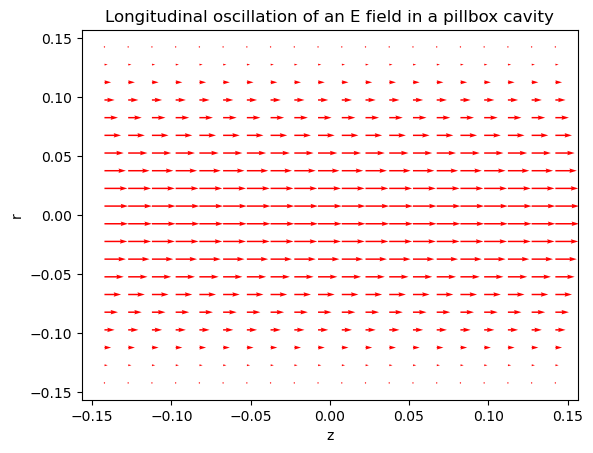

In [ ]:
nframes = 60

x_vals = np.linspace(-a, a, 20)
y_vals = np.linspace(-a, a, 20)
t_vals = np.linspace(0,period,nframes)

X, Y = np.meshgrid(x_vals,y_vals)
U = 0
V = 0

fig, ax = plt.subplots(1,1)

Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')
ax.set_ylabel('r')
ax.set_xlabel('z')
ax.set_title('Longitudinal oscillation of an E field in a pillbox cavity')

# this wrapper function lets us pass more stuff into our animation, like t_vals!
#def plot_field(y_vals, t_vals, nframes)

def update_quiver(frame_num, Q, X, Y):
    t = t_vals[frame_num]

    U = E_0 * special.jv(0, ((special.jn_zeros(0, 1) / a * Y))) * np.cos(t * 2 * np.pi * f)
    V = 0 * X

    Q.set_UVC(U,V)

    return Q,

anim = FuncAnimation(fig, update_quiver, fargs=(Q, X, Y), frames = nframes, interval=50)
display(HTML(anim.to_jshtml()))

<>:17: SyntaxWarning: invalid escape sequence '\z'
<>:17: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_358865/2761615723.py:17: SyntaxWarning: invalid escape sequence '\z'
  Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')
/home/ojc/miniconda3/envs/my-env/lib/python3.12/site-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/home/ojc/miniconda3/envs/my-env/lib/python3.12/site-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


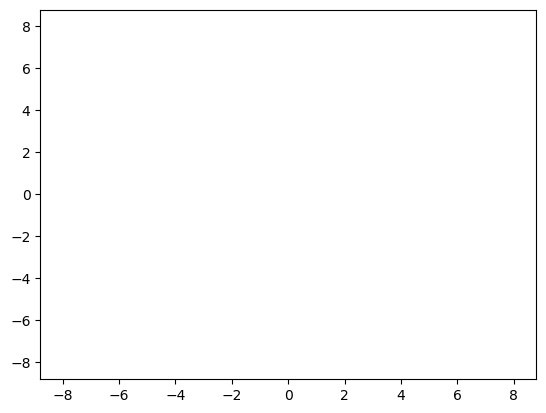

In [ ]:
x_vals = np.linspace(-8,8,20)
y_vals = np.linspace(-8,8,20)
#a = .142
#E_0 = 8e6
#f = 8e8

a = 300
f = 1/20
E_0 = 5

X, Y = np.meshgrid(x_vals,y_vals)
U = 0
V = 0

fig, ax = plt.subplots(1,1)

Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')

def function_of_H (E_0, z, r, a):
    H = (E_0 / 1) * special.jv(1, ((special.jn_zeros(0, 1)/a) * r))
    return H

def update_quiver(frame_num, Q, X, Y):
    theta = np.arctan(Y / X)
    phi = (np.pi / 2) + theta
    radius = np.sqrt(X**2 + Y**2)    
    
    #U = E_0 * special.jv(0, ((special.jn_zeros(0, 1) / a * Y))) * np.cos(frame_num * 2 * np.pi * f)
    #V = 0 * X

    H_x = function_of_H(E_0, 1,radius, a) * np.cos(phi + 0.1 * frame_num) 
    H_y = function_of_H(E_0, 1,radius, a) * np.sin(phi + 0.1 * frame_num) 

    #plt.quiver(X,Y, H_x, H_y, color='red', label='$H_{\phi}$')

    Q.set_UVC(H_x,H_y)

    return Q,

nframes = 60

#anim = FuncAnimation(fig, update_quiver, fargs=(Q, X, Y), frames = nframes, interval=50)
#display(HTML(anim.to_jshtml()))